In [6]:
from myutils import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.ticker as ticker
from src import *

In [7]:
data = read('yes.npy')

In [8]:
sigma = 22.39130434782609

In [49]:
di_x, spade_x = [], []
di_y, spade_y = [], []

spade_pn, di_pn = [LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d0.npz').photons.mean() for m in ('spade', 'di')]

for duty in np.arange(0, 101, 2):
    for m in ('spade', 'di'):
        c = LoadEstimates(f'__estimates__/noisy/{m}_5px/{m}_5px_f0.2_d{duty}.npz')
        if m == 'spade':
            spade_x.append(qCMOS.convert2photons(c.background.mean()))
            spade_y.append(c.estimates_a.var(ddof=1) * spade_pn)

        if m == 'di':
            di_x.append(qCMOS.convert2photons(c.background.mean()))
            di_y.append(c.estimates_a.var(ddof=1) * di_pn)

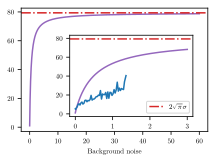

In [83]:

width = 8.5

c = '#9467bd'

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = plt.subplots(1, 1, figsize=(width / 2.54, width / 2.54 / 3 * 2))
ax.plot(data[0], data[1] , color=c)
ax.axhline(sqrt(pi) * (2*sigma), color='#d62728', linestyle='-.')
ax.set_xlim(None, None)
ax.set_ylim(None, None)

axins = inset_axes(ax, width='66%', height='66%', loc='center',
                bbox_to_anchor=(0.09, -0.05, 1, 1),
                bbox_transform=ax.transAxes)


axins.plot(data[0, :151], data[1, :151], color=c)
axins.axhline(sqrt(pi) * (2*sigma), color='#d62728', linestyle='-.', label=r'$2\sqrt{\pi}\sigma$')

mark_inset(ax, axins, loc1=2, loc2=3, fc='none')

axins.legend()

ax.set_xlabel('Background noise')
# ax.set_ylabel()
axins.plot(6.2*np.array(di_x)/di_pn, (6.2 * np.array(di_y)) / np.array(spade_y))
# plt.savefig('temp.pdf')
plt.show()

In [90]:
3 * (di_pn / qCMOS.CONVERSION_FACTOR) + 200

11813.5733

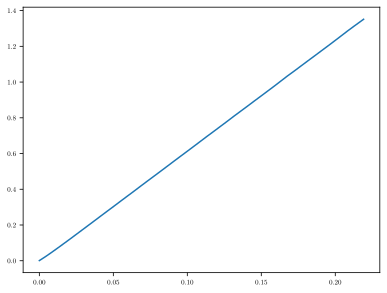

In [60]:
plot(np.array(di_x)/di_pn, np.array(spade_x)/spade_pn)

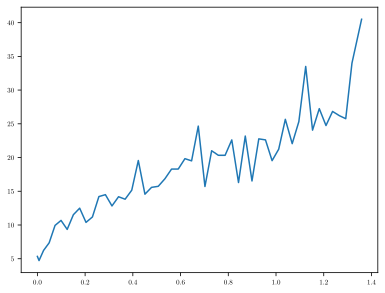

In [79]:

# plot(np.array(spade_x)/spade_pn, )

In [56]:
(spade_pn / di_pn) * np.array(di_x)

array([1.58711023e-11, 7.54154453e-02, 2.82967091e-01, 5.38596384e-01,
       8.06664776e-01, 1.08068296e+00, 1.36126767e+00, 1.64449711e+00,
       1.93156000e+00, 2.22130660e+00, 2.51437667e+00, 2.80991387e+00,
       3.10735483e+00, 3.40688612e+00, 3.70722847e+00, 4.00768613e+00,
       4.31078043e+00, 4.61045847e+00, 4.91307692e+00, 5.21513750e+00,
       5.52060116e+00, 5.82680241e+00, 6.12836899e+00, 6.43482008e+00,
       6.74024533e+00, 7.04422820e+00, 7.34949192e+00, 7.65442471e+00,
       7.96082776e+00, 8.26595119e+00, 8.57439309e+00, 8.88026798e+00,
       9.18751179e+00, 9.49680000e+00, 9.80305207e+00, 1.01140109e+01,
       1.04192107e+01, 1.07213008e+01, 1.10238348e+01, 1.13262685e+01,
       1.16403375e+01, 1.19435525e+01, 1.22569978e+01, 1.25695023e+01,
       1.28772335e+01, 1.31835247e+01, 1.34843892e+01, 1.37948680e+01,
       1.40859907e+01, 1.43704147e+01, 1.48103700e+01])

In [54]:
(di_pn*np.array(di_y))/(spade_pn*np.array(spade_y))

array([ 5.42848186,  4.80126794,  6.33275936,  7.47958807, 10.09829172,
       10.84981523,  9.49693136, 11.714608  , 12.69371792, 10.55549089,
       11.37190326, 14.44542606, 14.73035695, 13.0348497 , 14.41826046,
       14.04672424, 15.40482319, 19.87398165, 14.80494078, 15.83235095,
       15.9895326 , 17.13193029, 18.58577236, 18.59198761, 20.1566089 ,
       19.82614341, 25.05739591, 15.9636902 , 21.34706903, 20.66568568,
       20.66016767, 22.97779591, 16.56334459, 23.55851249, 16.80052946,
       23.13947142, 22.98512231, 19.85727039, 21.58508887, 26.08071309,
       22.42073313, 25.73469153, 34.04706201, 24.45781455, 27.69001426,
       25.14929463, 27.27204688, 26.63436665, 26.18112761, 34.5562591 ,
       41.16344092])